<a href="https://colab.research.google.com/github/RamaB47/Projet-Isigny-Ste-Mere/blob/main/matrice_Isigny.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import of libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

In [ ]:
dataset ="fichier_global_finalisé.csv"
df = pd.read_csv(dataset, sep=",")

In [ ]:
colonne = ["RR","NBRR","TX","TN", "TM", "Tx Lipides", "Tx Protéines"]

In [ ]:
df.head()

,Unnamed: 0.1,AAAAMM,RR,NBRR,TX,TN,TM,Unnamed: 0,Qté 1000L,Tx Lipides,Tx Protéines,cle_isigny,Prod_Isigny_Estimee
0,0,195802,64.2,18.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,195803,55.9,31.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,195804,25.9,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,195805,52.2,31.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,195806,100.9,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.tail(30)

,Unnamed: 0.1,AAAAMM,RR,NBRR,TX,TN,TM,Unnamed: 0,Qté 1000L,Tx Lipides,Tx Protéines,cle_isigny,Prod_Isigny_Estimee
792,792,202402,120.55,29.0,12.25,7.40,9.80,53.0,1929745.0,42.7,34.1,0.081036,22041792.0
793,793,202403,57.65,31.0,13.20,5.70,9.45,54.0,2092191.0,42.8,34.2,0.095062,25856864.0
794,794,202404,46.60,30.0,15.30,7.40,11.35,55.0,2049047.0,42.3,34.1,0.089157,24250704.0
795,795,202405,68.65,31.0,17.70,10.10,13.90,56.0,2093404.0,41.4,33.8,0.090543,24627696.0
796,796,202406,17.70,30.0,19.40,10.75,15.05,57.0,1934348.0,41.0,33.4,0.082624,22473728.0
797,797,202407,43.25,31.0,21.90,13.45,17.65,58.0,1900241.0,40.7,33.0,0.081430,22148960.0
798,798,202408,39.60,31.0,23.35,13.85,18.65,59.0,1810170.0,40.7,32.9,0.078105,21244560.0
799,799,202409,109.80,30.0,18.80,12.35,15.60,60.0,1752744.0,42.2,34.0,0.075205,20455760.0
800,800,202410,70.80,31.0,17.45,9.95,13.70,61.0,1828747.0,43.2,34.6,0.079266,21560352.0
801,801,202411,83.45,30.0,12.50,7.55,10.00,62.0,1792633.0,43.7,34.7,0.079266,21560352.0


In [ ]:
list(df.columns)

['Unnamed: 0.1',
 'AAAAMM',
 'RR',
 'NBRR',
 'TX',
 'TN',
 'TM',
 'Unnamed: 0',
 'Qté 1000L',
 'Tx Lipides',
 'Tx Protéines',
 'cle_isigny',
 'Prod_Isigny_Estimee']

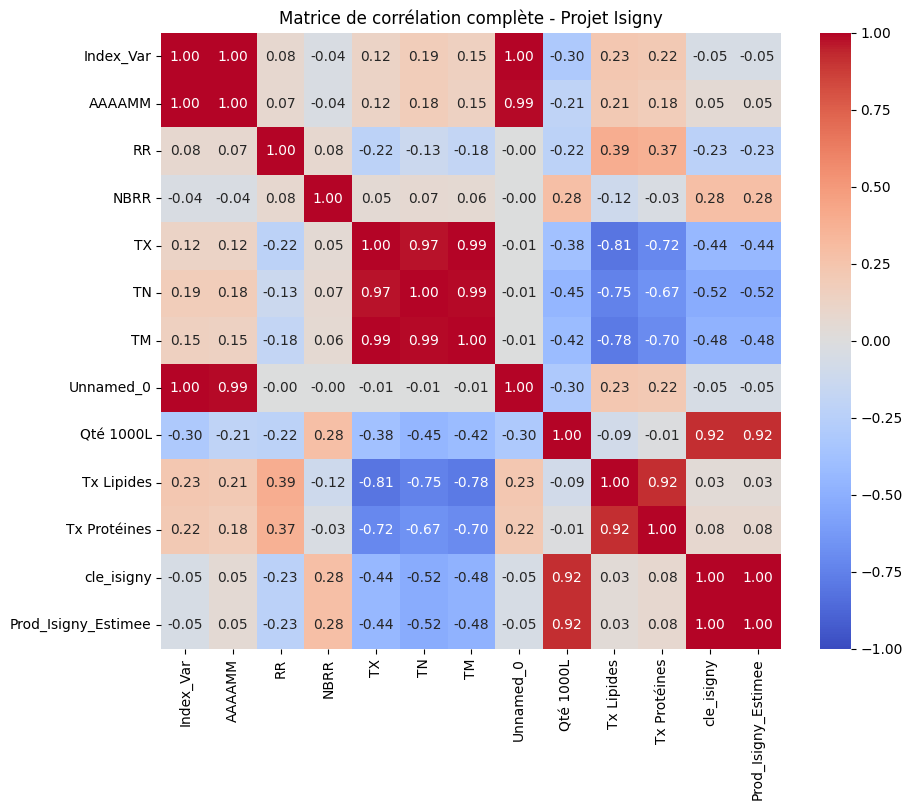

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# The DataFrame 'df' is now correctly loaded with multiple columns from the previous cell.
# We will directly rename its columns.

# 1. Define the desired column names
expected_column_names = [
    "Index_Var",
    "AAAAMM",
    "RR",
    "NBRR",
    "TX",
    "TN",
    "TM",
    "Unnamed_0", # This name aligns with the original intent for the column that was 'Unnamed: 0.1'
    "Qté 1000L",
    "Tx Lipides",
    "Tx Protéines",
    "cle_isigny",
    "Prod_Isigny_Estimee",
]

# Assign the new column names to the DataFrame
df.columns = expected_column_names

# 2. On convertit TOUTES les colonnes de chiffres en vrais nombres
colonnes_chiffres = [
    "RR",
    "NBRR",
    "TX",
    "TN",
    "TM",
    "Unnamed_0", # Use the new column name here
    "Qté 1000L",
    "cle_isigny",
    "Prod_Isigny_Estimee",
]
for col in colonnes_chiffres:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# 3. On extrait les colonnes numériques et on affiche ENFIN la matrice complète !
df_numerique = df.select_dtypes(include=["number"])
matrice_corr = df_numerique.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matrice_corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)

plt.title("Matrice de corrélation complète - Projet Isigny")
plt.show()

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression

# 1. Nettoyage des données (on s'assure d'éliminer les lignes vides sur ces colonnes)
df_simple = df[["TM", "Prod_Isigny_Estimee"]].dropna()

# 2. Définition des variables (X doit être un DataFrame/2D, y une série/1D)
X_simple = df_simple[["TM"]]
y_simple = df_simple["Prod_Isigny_Estimee"]

# 3. Entraînement du modèle
modele_simple = LinearRegression()
modele_simple.fit(X_simple, y_simple)

# 4. Extraction des indicateurs pour votre présentation
r2_simple = modele_simple.score(X_simple, y_simple)
pente = modele_simple.coef_[0]
ordonnee_origine = modele_simple.intercept_

print("--- RÉSULTATS RÉGRESSION SIMPLE ---")
print(f"Coefficient de détermination (R²) : {r2_simple:.4f}")
print(f"Impact d'un degré supplémentaire (Pente A) : {pente:.2f}")
print(f"Ligne de base (Constante B) : {ordonnee_origine:.2f}")

--- RÉSULTATS RÉGRESSION SIMPLE ---
Coefficient de détermination (R²) : 0.2278
Impact d'un degré supplémentaire (Pente A) : -176832.45
Ligne de base (Constante B) : 24902468.74


In [12]:
import pandas as pd
from prophet import Prophet

# 1. On crée le conteneur
df_prophet = pd.DataFrame()

# 2. On nettoie proprement la chaîne de caractères brute
# On enlève les espaces, les ".0" et on force le format YYYYMM-01
df_dates_brutes = (
    df["AAAAMM"].astype(str).str.split(".").str[0].str.strip().str.slice(stop=6)
)
dates_formatees = df_dates_brutes + "-01"

# 3. On convertit en spécifiant le format EXACT contenant le tiret (%Y%m-%d)
df_prophet["ds"] = pd.to_datetime(dates_formatees, format="%Y%m-%d")

# 4. On récupère le reste des données
df_prophet["y"] = pd.to_numeric(df["Prod_Isigny_Estimee"], errors="coerce")
df_prophet["TM"] = pd.to_numeric(df["TM"], errors="coerce")

# On nettoie les lignes vides
df_prophet = df_prophet.dropna()

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


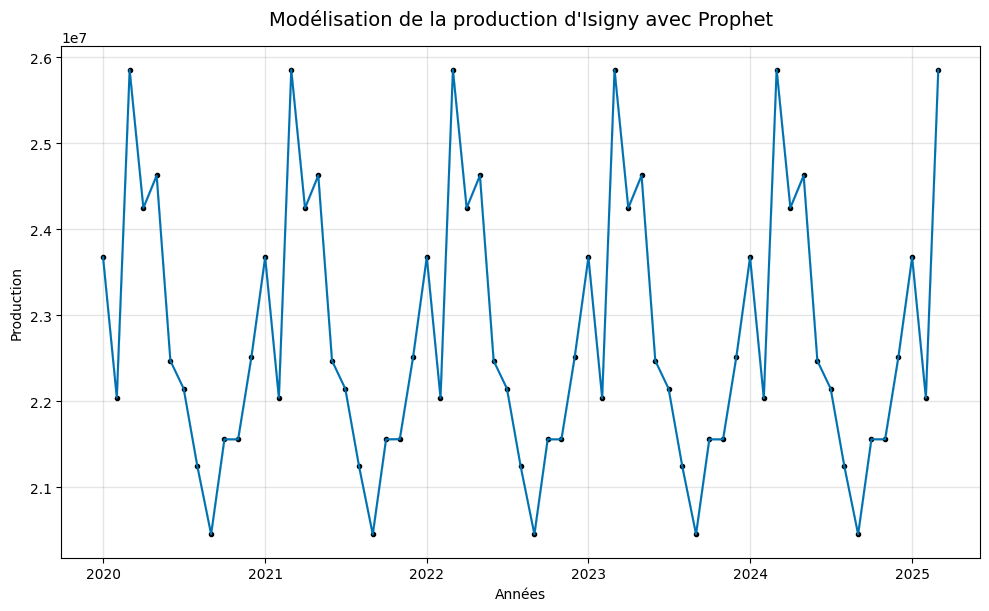

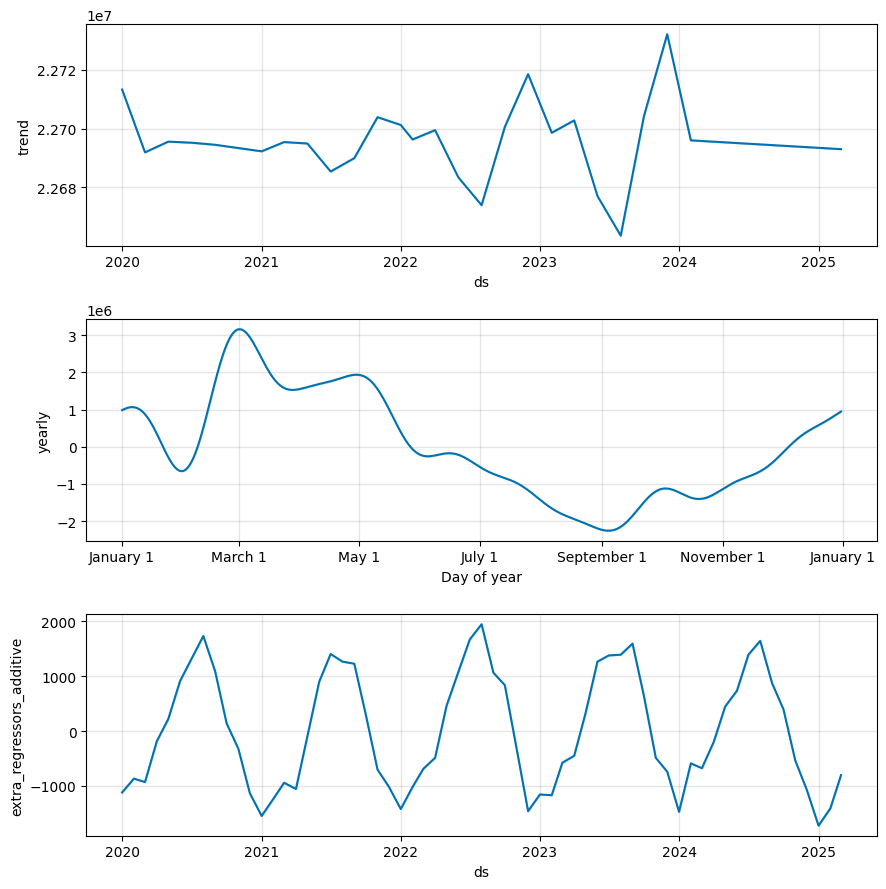

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
from prophet import Prophet

# ==============================================================================
# 1. PRÉPARATION DU DATAFRAME AU FORMAT STRICT PROPHET
# ==============================================================================
df_prophet = pd.DataFrame()

# Nettoyage rigoureux de la colonne temporelle pour éviter l'erreur de parsing
df_dates_brutes = (
    df["AAAAMM"].astype(str).str.split(".").str[0].str.strip().str.slice(stop=6)
)
dates_formatees = df_dates_brutes + "-01"

# Conversion finale avec le format exact (%Y%m-%d)
df_prophet["ds"] = pd.to_datetime(dates_formatees, format="%Y%m-%d")

# Récupération des données numériques (les cibles et régresseurs)
df_prophet["y"] = pd.to_numeric(df["Prod_Isigny_Estimee"], errors="coerce")
df_prophet["TM"] = pd.to_numeric(df["TM"], errors="coerce")

# Suppression des lignes vides
df_prophet = df_prophet.dropna()

# ==============================================================================
# 2. CONFIGURATION ET ENTRAÎNEMENT DU MODÈLE
# ==============================================================================
# On active la saisonnalité annuelle (indispensable pour les cycles du lait)
modele_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=False)

# On ajoute l'impact de la température comme variable externe
modele_prophet.add_regressor("TM")

# Entraînement du modèle
modele_prophet.fit(df_prophet)

# ==============================================================================
# 3. PRÉDICTIONS ET SÉPARATION DES COMPOSANTES
# ==============================================================================
# Calcul des prédictions sur l'historique
predictions = modele_prophet.predict(df_prophet)

# Graphique 1 : Courbe globale des prédictions (Points noirs = Réel, Ligne bleue = Modèle)
fig1 = modele_prophet.plot(predictions)
plt.title(
    "Modélisation de la production d'Isigny avec Prophet",
    fontsize=14,
    pad=15,
)
plt.xlabel("Années")
plt.ylabel("Production")
plt.show()

# Graphique 2 : Décomposition (Tendance de fond VS Saisonnalité annuelle VS Impact de la météo)
fig2 = modele_prophet.plot_components(predictions)
plt.show()

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


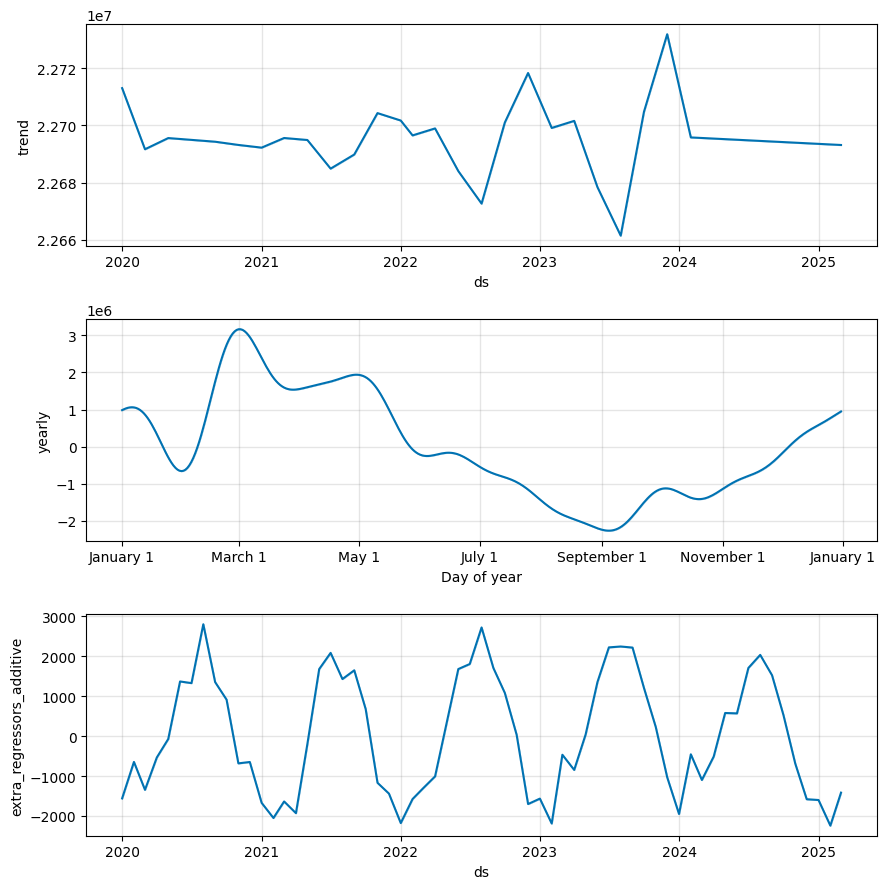

In [ ]:
# ==============================================================================
# 1. PRÉPARATION DU DATAFRAME AVEC LA PLUVIOMÉTRIE (RR)
# ==============================================================================
df_prophet = pd.DataFrame()

df_dates_brutes = (
    df["AAAAMM"].astype(str).str.split(".").str[0].str.strip().str.slice(stop=6)
)
dates_formatees = df_dates_brutes + "-01"
df_prophet["ds"] = pd.to_datetime(dates_formatees, format="%Y%m-%d")

# On récupère la cible et NOS DEUX variables climatiques
df_prophet["y"] = pd.to_numeric(df["Prod_Isigny_Estimee"], errors="coerce")
df_prophet["TM"] = pd.to_numeric(df["TM"], errors="coerce")
df_prophet["RR"] = pd.to_numeric(
    df["RR"], errors="coerce"
)  # <-- Ajout de la pluie

df_prophet = df_prophet.dropna()

# ==============================================================================
# 2. CONFIGURATION ET MULTI-RÉGRESSEURS
# ==============================================================================
modele_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=False)

# On déclare les deux variables à Prophet
modele_prophet.add_regressor("TM")
modele_prophet.add_regressor("RR")  # <-- On dit à Prophet de tester la pluie

modele_prophet.fit(df_prophet)

# ==============================================================================
# 3. PRÉDICTIONS ET SÉPARATION DES COMPOSANTES
# ==============================================================================
predictions = modele_prophet.predict(df_prophet)

# Affichage des composants (Tendance, Saisonnalité, Effet TM, Effet RR)
fig2 = modele_prophet.plot_components(predictions)
plt.show()

In [14]:
import pandas as pd

# 1. On charge le vrai DataFrame à partir du chemin de fichier contenu dans dataset
df_origine_propre = pd.read_csv(dataset) # ou pd.read_excel(dataset) si c'est un Excel

# 2. Si votre colonne de date s'appelle 'AAAAMM', on la renomme en 'ds'
if 'AAAAMM' in df_origine_propre.columns:
    df_origine_propre = df_origine_propre.rename(columns={'AAAAMM': 'ds'})

# 3. On harmonise les formats de date pour éviter les conflits
df_prophet['ds'] = df_prophet['ds'].astype(str)
df_origine_propre['ds'] = df_origine_propre['ds'].astype(str)

# 4. Fusion finale
df_powerbi = pd.merge(df_prophet, df_origine_propre, on='ds', how='left')

print(df_powerbi.head())

           ds           y   TM_x  Unnamed: 0.1  RR  NBRR  TX  TN  TM_y  \
0  2020-01-01  23676784.0   7.70           NaN NaN   NaN NaN NaN   NaN   
1  2020-02-01  22041792.0   8.70           NaN NaN   NaN NaN NaN   NaN   
2  2020-03-01  25856864.0   8.45           NaN NaN   NaN NaN NaN   NaN   
3  2020-04-01  24250704.0  11.40           NaN NaN   NaN NaN NaN   NaN   
4  2020-05-01  24627696.0  13.00           NaN NaN   NaN NaN NaN   NaN   

   Unnamed: 0  Qté 1000L  Tx Lipides  Tx Protéines  cle_isigny  \
0         NaN        NaN         NaN           NaN         NaN   
1         NaN        NaN         NaN           NaN         NaN   
2         NaN        NaN         NaN           NaN         NaN   
3         NaN        NaN         NaN           NaN         NaN   
4         NaN        NaN         NaN           NaN         NaN   

   Prod_Isigny_Estimee  
0                  NaN  
1                  NaN  
2                  NaN  
3                  NaN  
4                  NaN  


In [15]:
df_powerbi.to_csv("fichier_prédictif_Isigny.csv")